In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("./data/housing.csv")

In [3]:
data

,Unnamed: 0,beds,baths,size,zip_code,price
0,0,3,2.5,2590.0,98144,795000.0
1,1,4,2.0,2240.0,98106,915000.0
2,2,4,3.0,2040.0,98107,950000.0
3,3,4,3.0,3800.0,98199,1950000.0
4,4,2,2.0,1042.0,98102,950000.0
...,...,...,...,...,...,...
2011,2011,3,2.0,1370.0,98112,910000.0
2012,2012,1,1.0,889.0,98121,550000.0
2013,2013,4,2.0,2140.0,98199,1150000.0
2014,2014,2,2.0,795.0,98103,590000.0


In [5]:
data["zip_code"].value_counts()

zip_code
98115    170
98103    166
98117    151
98144    113
98122    109
98118    100
98116     88
98107     83
98126     80
98106     78
98125     78
98105     73
98199     72
98119     70
98133     61
98109     61
98102     60
98136     60
98121     59
98112     57
98178     44
98168     44
98146     41
98108     33
98177     27
98101     23
98104     14
98164      1
Name: count, dtype: int64

In [10]:
data = data.drop(columns=["Unnamed: 0"])

In [11]:
data

,beds,baths,size,zip_code,price
0,3,2.5,2590.0,98144,795000.0
1,4,2.0,2240.0,98106,915000.0
2,4,3.0,2040.0,98107,950000.0
3,4,3.0,3800.0,98199,1950000.0
4,2,2.0,1042.0,98102,950000.0
...,...,...,...,...,...
2011,3,2.0,1370.0,98112,910000.0
2012,1,1.0,889.0,98121,550000.0
2013,4,2.0,2140.0,98199,1150000.0
2014,2,2.0,795.0,98103,590000.0


In [12]:
nd_data = np.array(data)

In [25]:
def feature_scaling(data):
    x = data

    mean_ = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    print(mean_.size, std.size)
    x_scaled = (x - mean_) / std

    return x_scaled, mean_, std

In [26]:
nd_scaled, f_mean, f_std = feature_scaling(nd_data)

5 5


In [64]:
def gradient_descent(x_train, y_train, w, b):

    m, n = x_train.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        pred = (x_train[i]@w) + b
        err = pred - y_train[i]
        dw = err * x_train[i]
        db = err
        dj_dw += dw
        dj_db += db

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db
        

In [65]:
def run_gradient_descent(x_train, y_train, w, b, alpha, epochs):

    for i in range(epochs):
        if i%50 == 0:
            print(i, w, b)
        now_w, now_b = gradient_descent(x_train, y_train, w, b)

        w = w - alpha * now_w
        b = b - alpha * now_b

    return w, b

In [66]:
x_train = nd_scaled[:, :-1]
y_train = nd_scaled[:, -1]

print(x_train.shape, y_train.shape)
print(x_train, y_train)

(2016, 4) (2016,)
[[ 0.11345495  0.33942758  0.9286394   0.89913582]
 [ 0.91040676 -0.15968693  0.54816506 -0.77892394]
 [ 0.91040676  0.83854209  0.33075115 -0.73476447]
 ...
 [ 0.91040676 -0.15968693  0.4394581   3.32790652]
 [-0.68349687 -0.15968693 -1.02265042 -0.91140234]
 [ 0.11345495 -0.15968693 -0.0279818   0.41338168]] [-0.17865468 -0.05151734 -0.01443562 ...  0.19745993 -0.39584762
 -0.32274365]


In [69]:
w = [0, 0, 0, 0]
b = 0
alpha = 0.01
epochs = 1000

w, b = run_gradient_descent(x_train, y_train, w, b, alpha, epochs)

0 [0, 0, 0, 0] 0
50 [ 0.07474522  0.08929457  0.14557908 -0.02255978] -3.501456730379377e-16
100 [ 0.07923039  0.10999853  0.21284947 -0.03978419] -1.1278935237279086e-15
150 [ 0.06462758  0.11098879  0.25414708 -0.05138683] -2.0007378139591965e-15
200 [ 0.04594589  0.1067666   0.28531792 -0.05885694] -2.7898139596531595e-15
250 [ 0.02748578  0.10159583  0.31134527 -0.06359215] -3.435674914758604e-15
300 [ 0.01038599  0.09668512  0.33395574 -0.06658837] -3.930221723466177e-15
350 [-0.00513999  0.09233084  0.35387993 -0.06849526] -4.2982851625404255e-15
400 [-0.01914177  0.08855963  0.37152673 -0.06972195] -4.564328137227818e-15
450 [-0.0317368   0.08532244  0.38718679 -0.07052253] -4.755698976156523e-15
500 [-0.04305331  0.08255357  0.40109567 -0.07105414] -4.885418844160739e-15
550 [-0.05321416  0.0801885   0.41345508 -0.07141408] -4.9796625156695004e-15
600 [-0.06233274  0.07816902  0.42444133 -0.07166288] -5.044863061249354e-15
650 [-0.07051246  0.07644429  0.43420968 -0.0718385 ] -

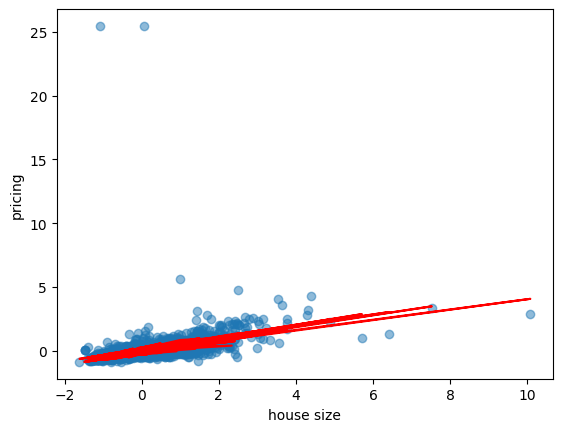

In [73]:
plt.scatter(x_train[:, 2], y_train, alpha=0.5, label="actual value")
plt.plot(x_train[:, 2], gradient_pred, color='red', label="prediction")
plt.xlabel("house size")
plt.ylabel("pricing")
plt.show()

In [72]:
gradient_pred = x_train@w+b

In [83]:
x = [3, 2.0, 1370.0, 98112]

In [84]:
s = (x-f_mean[:-1])/f_std[:-1]
s

array([ 0.11345495, -0.15968693, -0.39758544, -0.51396713])

In [85]:
((s@w+b)*f_std[-1])+f_mean[-1]

np.float64(797122.5744197742)